In [1]:
!pip install -q imbalanced-learn --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 73.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.8.0 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


# **1. Load Data**

In [3]:
df = pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
print(f"Shape: {df.shape}")

Shape: (7043, 21)


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **2. Exploratory Data Analysis**

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Class Distribution ---
# First thing to check: how imbalanced is the dataset?
# This determines which strategy we use to handle imbalance later.

In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

Churn Distribution:
       Count  Percentage
Churn                   
No      5174        73.5
Yes     1869        26.5


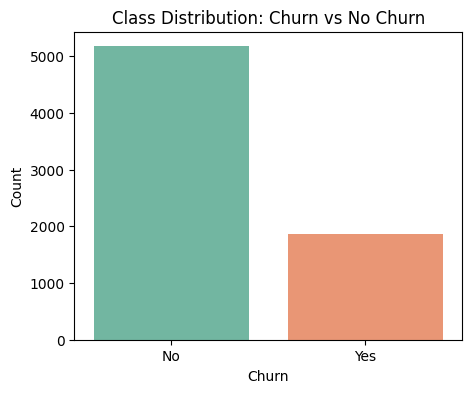

In [8]:
print("Churn Distribution:")
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(1)}))

plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Class Distribution: Churn vs No Churn')
plt.ylabel('Count')
plt.show()

# --- Churn rate by Contract type ---
# Hypothesis: month-to-month customers have no lock-in, so they should churn more.

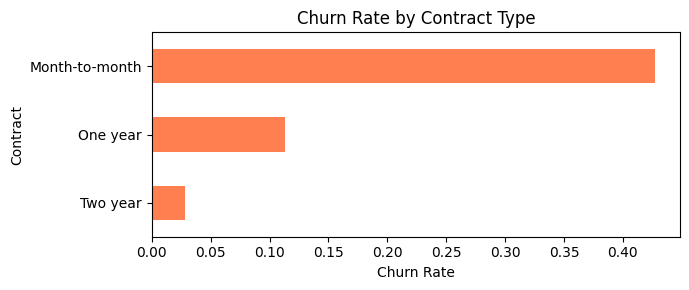

In [9]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn['Yes'].sort_values().plot(kind='barh', color='coral', figsize=(7, 3))
plt.title('Churn Rate by Contract Type')
plt.xlabel('Churn Rate')
plt.tight_layout()
plt.show()

# --- Numeric feature distributions split by churn label ---
# Looking at how tenure, MonthlyCharges, and TotalCharges differ between churners and non-churners.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

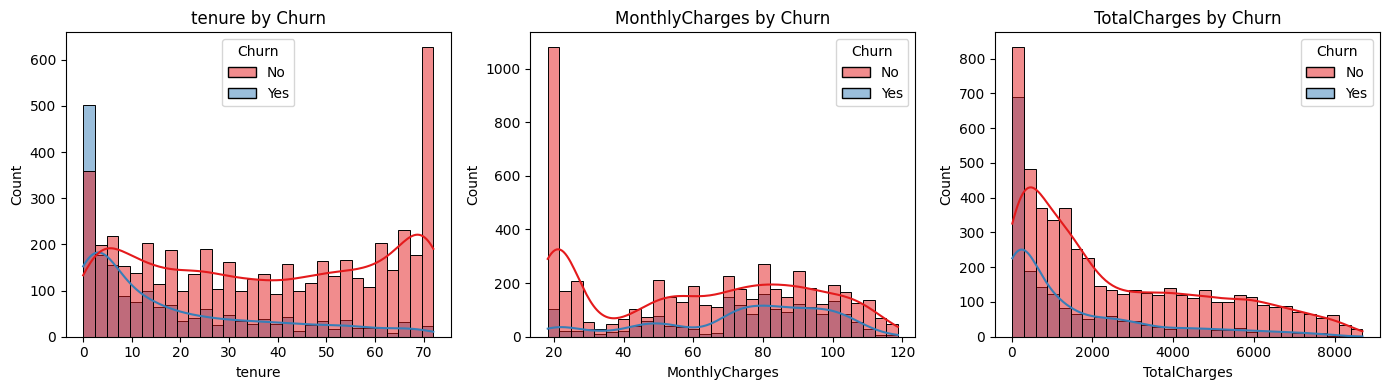

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    temp = df.copy()
    temp[col] = pd.to_numeric(temp[col], errors='coerce')
    temp.dropna(subset=[col], inplace=True)
    sns.histplot(data=temp, x=col, hue='Churn', kde=True, ax=ax, palette='Set1', bins=30)
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

# **3. Data Cleaning**

# TotalCharges is stored as string in the raw CSV (some new customers have blank entries).
# Coerce converts blanks to NaN so we can handle them explicitly.

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


# Only 11 rows affected — safe to drop (< 0.2% of data)


In [12]:
print(f"Missing TotalCharges rows: {df['TotalCharges'].isna().sum()}")
df.dropna(inplace=True)
print(f"Shape after dropping NaNs: {df.shape}")

Missing TotalCharges rows: 11
Shape after dropping NaNs: (7032, 21)


# customerID is a unique identifier — carries zero predictive signal


In [13]:
df.drop('customerID', axis=1, inplace=True)

# **4. Encoding**

In [14]:
from sklearn.preprocessing import LabelEncoder

# Separate binary from multi-class categorical columns
binary_cols = [col for col in df.select_dtypes('object').columns
               if df[col].nunique() == 2 and col != 'Churn']
multiclass_cols = [col for col in df.select_dtypes('object').columns
                   if df[col].nunique() > 2 and col != 'Churn']

print(f"Binary columns   (LabelEncoder) : {binary_cols}")
print(f"Multi-class cols (One-Hot)       : {multiclass_cols}")

Binary columns   (LabelEncoder) : ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-class cols (One-Hot)       : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [15]:
le = LabelEncoder()

# LabelEncoder is appropriate only for binary columns
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Encode target: No -> 0, Yes -> 1
df['Churn'] = le.fit_transform(df['Churn'])

# One-Hot Encode multi-class nominal columns
# drop_first=True drops one dummy per group to avoid multicollinearity
df = pd.get_dummies(df, columns=multiclass_cols, drop_first=True)

print(f"Shape after encoding: {df.shape}")
df.head(2)

Shape after encoding: (7032, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True


# **5. Train/Test Split**

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]} rows")
print(f"Train churn rate : {y_train.mean():.2%}")
print(f"Test  churn rate : {y_test.mean():.2%}")

Train size : 5274 rows
Test  size : 1758 rows
Train churn rate : 26.58%
Test  churn rate : 26.56%


# **6. SMOTE — Applied Only on Training Data**

In [17]:
from imblearn.over_sampling import SMOTE

print(f"Before SMOTE — Class 0 (No Churn): {(y_train==0).sum()}, Class 1 (Churn): {(y_train==1).sum()}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"After  SMOTE — Class 0 (No Churn): {(y_train_res==0).sum()}, Class 1 (Churn): {(y_train_res==1).sum()}")

Before SMOTE — Class 0 (No Churn): 3872, Class 1 (Churn): 1402
After  SMOTE — Class 0 (No Churn): 3872, Class 1 (Churn): 3872


# **7. Model Training**

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_res, y_train_res)
print("Model trained successfully.")

Model trained successfully.


# **8. Evaluation**

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

print("Classification Report (held-out test set):")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Classification Report (held-out test set):
              precision    recall  f1-score   support

    No Churn       0.85      0.83      0.84      1291
       Churn       0.55      0.59      0.57       467

    accuracy                           0.76      1758
   macro avg       0.70      0.71      0.70      1758
weighted avg       0.77      0.76      0.77      1758



# Confusion Matrix

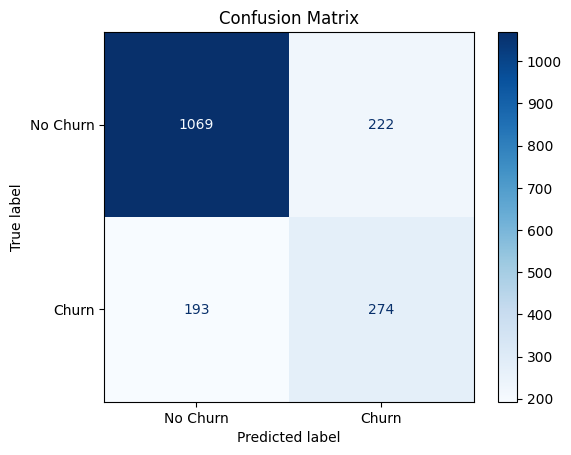

In [20]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# **9. Cross-Validation**

In [21]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_recall = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall')

print(f"CV Recall per fold : {cv_recall.round(3)}")
print(f"Mean Recall        : {cv_recall.mean():.3f}")
print(f"Std Dev            : {cv_recall.std():.3f}")

CV Recall per fold : [0.47  0.438 0.493 0.514 0.546]
Mean Recall        : 0.492
Std Dev            : 0.037


# **10. Feature Importance**

In [22]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top5 = importances.sort_values(ascending=False).head(5)

Top 5 Predictors of Churn:
TotalCharges                      0.164634
tenure                            0.147491
MonthlyCharges                    0.134405
PaymentMethod_Electronic check    0.096704
InternetService_Fiber optic       0.055707
dtype: float64


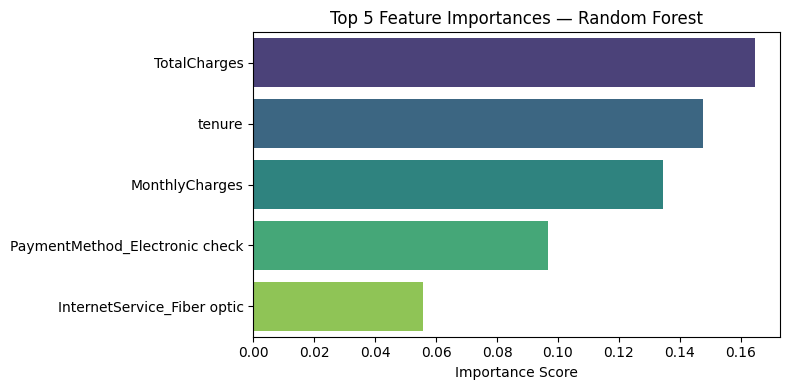

In [23]:
print("Top 5 Predictors of Churn:")
print(top5)

plt.figure(figsize=(8, 4))
sns.barplot(x=top5.values, y=top5.index, palette='viridis')
plt.title('Top 5 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()